In [4]:
# Машинное обучение

# ML решает задачу: Требуетс подогнать заданный набор точек данными под соответсвующую функцию (отображение входа на выход), которая 
# улавливает важные сигналы в данных и игнорирует помехи, а затем убедиться, что на новых данных функция работает хорошо.

# Обучение с учителем (supervised learning)
# Обучение без учителя (unsupervised learning)

# ОчУ - моделирует отношение между признаками и метками. Такие модели служат для предсказания меток на основе обучающих данных маркированных.
# После построения модели можно использовать её для присвоения меток новым ранее неизвестным данным.

# - задачи классификации (метки - дискретные: два или более)
# - задачи регрессии (метки/результат; непрерывные величины)

# ОбУ - моделирование признаки без меток. Такие модели служат для выявления структуры немаркированных данных

# - задачи кластеризации (выделяет отдельные группы данных)
# - понижения размерности (поиск более сжатого предстваления данных)

# Существуют методы частичного обучения (semi-supervised learning). Не все данные промаркерованы

# Методы обучения с подкрепоением (reinforcement learning). Система обучения улучшает свои характеристики на основе взаимодействия (обратной связи)
# со средой. При этом взаимодействии система получает сигналы (функции наград), которые несут в себе информацию насколько хорошо/плохо система решила 
# задачу ( с точки зрения среды). Итоговая награда не станет максиммальной

In [7]:
import seaborn as sns
iris = sns.load_dataset("iris")

print(iris.head())
print(type(iris))

print(type(iris.values))
print(iris.values.shape)
print(iris.index)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
(150, 5)
RangeIndex(start=0, stop=150, step=1)


In [8]:
# Строки - отдельные объекты - образцы (sample)
# Столбцы - признаки (features) - соответствуют конкретным наблюдениям
# Матрицы признаков (features matrix) размер [число образцов х число признаков]
# Целевой массив, массив меток (targets) - одномерный массив [1 х число образцов] - данные, которые мы хотим предсказать на основе имеющихся данных
# Зависимые (метка) и независимые переменные (признаки)


# Процесс простроения системы машинного обучения 

# 1. Предварительная обработка
# - на вход поступают необработанные данные и метки
# - происходит выбор признаков, масштабирование признаков
# - понижение размерности
# - выборка образцов
# - на выход набор данных: обучающий, тестовый

# 2. Обучение
# - выюор модели
# - прекрестная проверка
# - метрики эффективности
# - оптимизация гиперпараметров. Параметры, которые получаются не из данных, а являются характеристиками моделей

# 3. Оценка и формирование финальной модели

# 4. Прогнозирование (использование модели)


# SciKit-learn

# 1. выбираем класс модели
# 2. устанавливаем гиперпараметры модели
# 3. создаём матрицу признаков и целевой массив 
# 4. обучение модели fit()
# 5. применять модель к новым данным 
# - predict() (с учителем)
# - predict() или transform() (без учителя)


# Обучение с учителем: Линейная регрессия

#     Простой линейной регрессии

# y = ax + b

In [9]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
x = 10 * np.random.rand(50)
y = 2 * x + np.random.randn(50)

2.0272088103606953
0.0014229144467954313


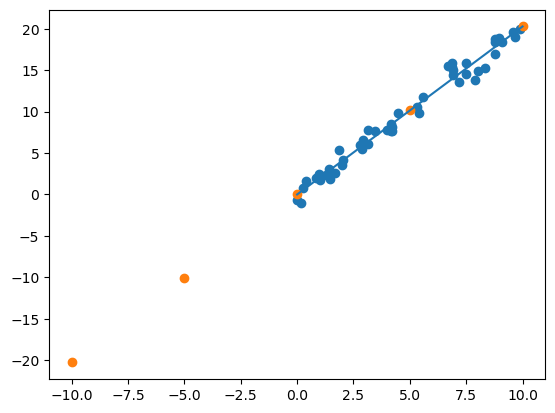

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = x[:, np.newaxis]
model.fit(X, y)
print(model.coef_[0])
print(model.intercept_)
x_ = np.linspace(0, 10, 30)
y_ = model.coef_[0] * x_ + model.intercept_ 

xfit = np.linspace(-10, 10, 5)
yfit = model.predict(xfit[:, np.newaxis])

plt.plot(x_, y_)
plt.scatter(x, y)
plt.scatter(xfit, yfit)
plt.show()

In [4]:
# линейная регрессия

# Задача: на основе наблюдаемых точек построить прямую, которая отражает связь между переменными
# лин.регрессия подгоняет данные к прямой линии, пытаясь установить линейную связь.

import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [6]:
features, target = make_regression(n_samples=100, n_features=1,n_informative=1, n_targets=1, noise=1, random_state=1)
print(features.shape)
print(target.shape)

(100, 1)
(100,)


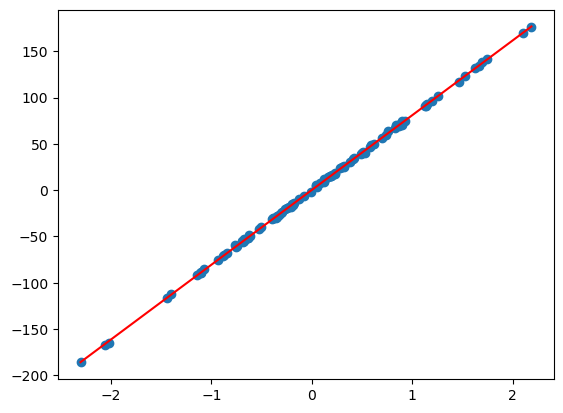

In [8]:
model = LinearRegression().fit(features, target)
plt.scatter(features, target)
x = np.linspace(features.min(), features.max(), 100)
plt.plot(x, model.coef_[0] * x + model.intercept_, color='red')
plt.show()

In [26]:
# # Простая линейная регрессия

# Линейная -> линейная зависимость

# + прогнозирование на новых данных
# + анализ взаимного влияния пременных друг на друга

# - точки обучаемых данных НЕ будут точно лежать на прямой (шума) -> область погрешности
# - НЕ позволяет делать прогнозы ВНЕ диапазона имеющихся данных

In [10]:
data = np.array([[1,5], 
                 [2, 7],
                 [3, 7],
                 [4, 10],
                 [5, 11], 
                 [6, 14],
                 [7, 17], 
                 [8, 19], 
                 [9, 22],
                 [10, 28]])
x = data[:, 0]
y = data[:, 1]
n = len(x)
w1 = (n * sum(x[i] * y[i]for i in range(n)) - sum(x[i] for i in range(n)) * sum(y[i] for i in range(n)))
w2 = (n * sum(x[i] ** 2 for i in range(n)) - sum(x[i] for i in range(n))**2)
w_1 = w1/w2
w_0 = (sum(y[i] for i in range(n)) / n) - w_1 * (sum(x[i] for i in range(n))) / n
print(w_1, w_0)

2.4 0.8000000000000007


In [12]:
from numpy.linalg import inv, qr
x_1 = np.vstack([x, np.ones(len(x))]).T
w = inv(x_1.transpose() @ x_1) @ (x_1.transpose() @ y)
print(w)

[2.4 0.8]


In [14]:
Q, R = qr(x_1)
w = inv(R).dot(Q.transpose()).dot(y)
print(w)

[2.4 0.8]


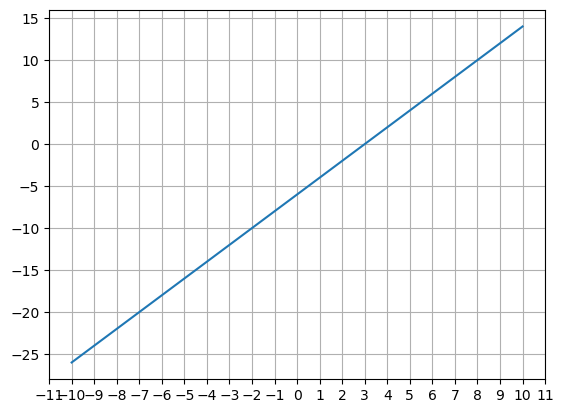

In [16]:
def f(x):
    return (x-3)**2 + 4
def dx_f(x):
    return 2*x - 6


x = np.linspace(-10, 10, 100)
ax = plt.gca()
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
#plt.plot(x, f(x))
plt.plot(x, dx_f(x))
plt.grid()
plt.show()

In [18]:
import random
L = 0.001
iterations = 100_000
x = random.randint(0, 5)
for i in range(iterations):
    d_x = dx_f(x)
    x -= L * d_x
print(x, f(x))

2.999999999999889 4.0


In [20]:
data = np.array([[1,5], 
                 [2, 7],
                 [3, 7],
                 [4, 10],
                 [5, 11], 
                 [6, 14],
                 [7, 17], 
                 [8, 19], 
                 [9, 22],
                 [10, 28]])
x = data[:, 0]
y = data[:, 1]
L = 0.001
iterations = 1_000
w1 = 0.0
w0 = 0.0
for i in range(iterations):
    D_w0 = 2 * sum(y[i] - w0 - w1 * x[i] for i in range(n))
    D_w1 = 2 * sum(x[i] * (-y[i] - w0 - w1 * x[i]) for i in range(n))
    w1 -= L*D_w1
    w0 -=L*D_w0
print(w1, w0)


1.6089294778152133e+252 2.3110751647046325e+251


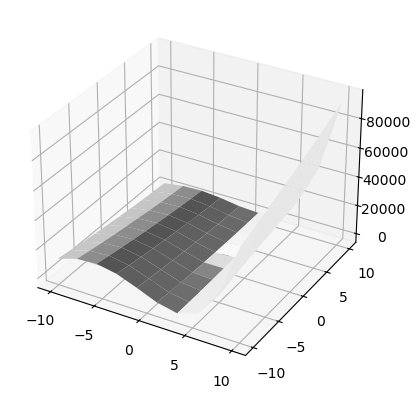

In [22]:
w1 = np.linspace(-10, 10, 10)
w0 = np.linspace(-10, 10, 10)
def E(w1, w0, x, y):
    return sum((y[i] - (w0 + w1 * x)) ** 2 for i in range(len(x)))

W1, W0 = np.meshgrid(w1, w0)
EW = E(W1, W0, x, y)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(W1, W0, EW, color='white')
w1_fit = 2.4
w0_fit = 0.8
E_fit= E(w1_fit, w0_fit,x, y)
ax.scatter3D(w1_fit, w0_fit, E_fit, color='red')
plt.show()

In [30]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

data = np.array([[1,5], 
                 [2, 7],
                 [3, 7],
                 [4, 10],
                 [5, 11], 
                 [6, 14],
                 [7, 17], 
                 [8, 19], 
                 [9, 22],
                 [10, 28]])

# градиентный спуск - пакетный градиентный спуск. для работы используются ВСЕ доступные обучающие данные.
# стохастический градиентный спуск, на каждой итерации обучаемся тролько на одной выборке из данных
# мини - пакетный градиентный спуск. на каждой итерации используется несколько выборок.

In [32]:
x = data[:, 0]
y = data[:, 1]
n = len(x)
w1 = 0.0
w0 = 0.0
L = 0.001
sample_size = 1
iterations = 100_000
for i in range(iterations):
    idx = np.random.choice(n, sample_size, replace=False)
    D_w0 = 2 * sum(-y[idx] + w0 + w1 * x[idx])
    D_w1 = 2 * sum(x[idx]  * (-y[idx] + w0 + w1 * x[idx]))
    w1 -= L * D_w1
    w0 -= L * D_w0

print(w1, w0)

2.4470678686984937 0.822303083352681


In [33]:
# как оценить насколько сильно промахиваются прогнозы
data_df = pd.DataFrame(data)
print(data_df.corr(method='pearson'))
# коэфф корреляции помогает понять есть ли связь между двумя переменными

         0        1
0  1.00000  0.97684
1  0.97684  1.00000


In [36]:
data_df[1] = (data_df[1].values[::-1])
print(data_df.corr(method='pearson'))

         0        1
0  1.00000 -0.97684
1 -0.97684  1.00000


In [38]:
# обучающие и тестовые выборки - основной метод борьбы с переобучением
X = data_df.values[:, :-1]
Y = data_df.values[:, 1]
print(X)
print(Y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[28 22 19 17 14 11 10  7  7  5]


In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 1/3)

model = LinearRegression()
model.fit(X_train, Y_train)
r = model.score(X_test, Y_test)
print(r)

0.9077893088441972


In [42]:
from sklearn.model_selection import KFold, cross_val_score
kfold = KFold(n_splits=3, random_state=1, shuffle=True)
model = LinearRegression()
result = cross_val_score(model, X, Y, cv=kfold)
print(result) # средние квадратические ошибки
print(result.mean(), result.std())

[0.89496072 0.31490412 0.35603912]
0.5219679891091406 0.26427978429978516


In [44]:
# поэлементная перекрестная валидация - мало данных
# случайная валидация - перемешиваем данные и используем несколько раз

In [49]:
X = data_df.values[:,:-1]
Y = data_df.values[:, -1]
model = LinearRegression().fit(X, Y)
print(model.coef_, model.intercept_)

[-2.4] 27.199999999999996


10 10
10 10 10


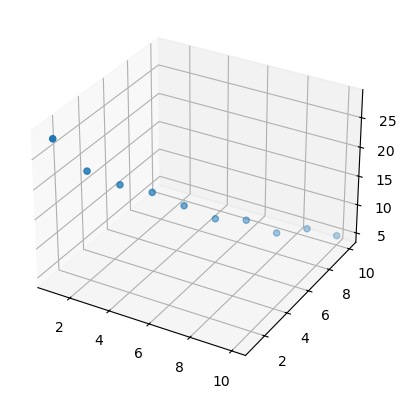

<Figure size 640x480 with 0 Axes>

In [57]:
fig = plt.figure()
ax = plt.axes(projection='3d')
x1 = X[:, 0]
x2 = X[:, 0]
y = Y
print(len(X), len(Y))
print(len(x1), len(x2), len(y))
fig = plt.figure()
ax.scatter3D(x1, x2, y)

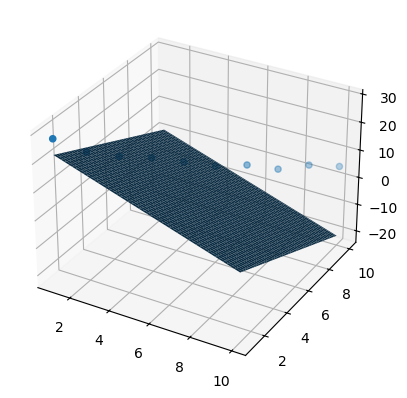

In [61]:
x1_ = np.linspace(min(x1), max(x1), 100)
x2_ = np.linspace(min(x2), max(x2), 100)
X1_, X2_ = np.meshgrid(x1_, x2_)
Y_ = model.intercept_ + model.coef_[0]*X1_ + model.coef_[0]*X2_
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(x1, x2, y)
ax.plot_surface(X1_, X2_, Y_)
plt.show()